# Кластеризация: датасет Glass Identification (UCI)

Лабораторная работа по кластерному анализу на основе датасета Glass Identification (состав и показатель преломления стекла).

## Загрузка данных

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"

try:
    df = pd.read_csv(url, header=None)
except Exception:
    df = pd.read_csv("glass.data", header=None)

cols = ["Id", "RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe", "Type"]
df.columns = cols
df = df.dropna().reset_index(drop=True)

df["Id"] = df["Id"].astype(int)
df["Type"] = df["Type"].astype(int)

df.head()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


Датасет содержит **214 наблюдений**. В исходном файле есть колонка **Id** (идентификатор образца), которую нельзя использовать как признак для кластеризации. Колонка **Type** отражает тип стекла и используется как «истинная метка» только для проверки качества кластеров (ARI/NMI), но в признаки не включается.

## Дескриптивный анализ

In [3]:
print("Размерность (строки, столбцы):", df.shape)
display(df.info())

missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))

display(df.describe())
display(df["Type"].value_counts().sort_index().to_frame("count"))

Размерность (строки, столбцы): (214, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      214 non-null    int64  
 1   RI      214 non-null    float64
 2   Na      214 non-null    float64
 3   Mg      214 non-null    float64
 4   Al      214 non-null    float64
 5   Si      214 non-null    float64
 6   K       214 non-null    float64
 7   Ca      214 non-null    float64
 8   Ba      214 non-null    float64
 9   Fe      214 non-null    float64
 10  Type    214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB


None

,missing_count
Id,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0


,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


,count
Type,
1,70
2,76
3,17
5,13
6,9
7,29


## Подготовка признаков

In [4]:
y_true = df["Type"].copy()
X = df.drop(columns=["Type", "Id"]).copy()

X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


## Гистограммы признаков

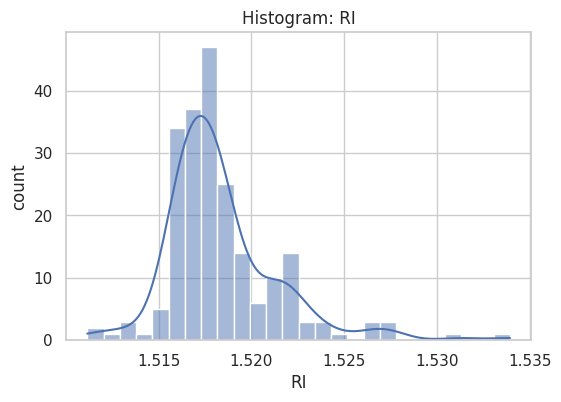

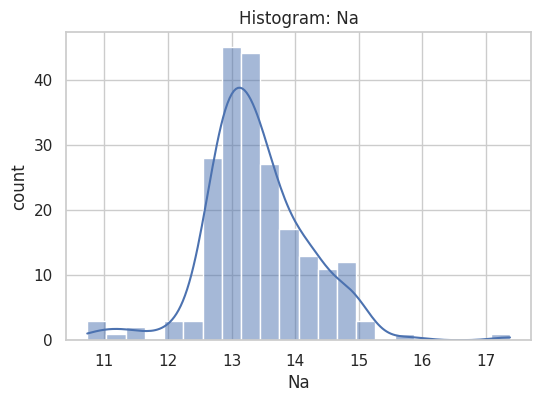

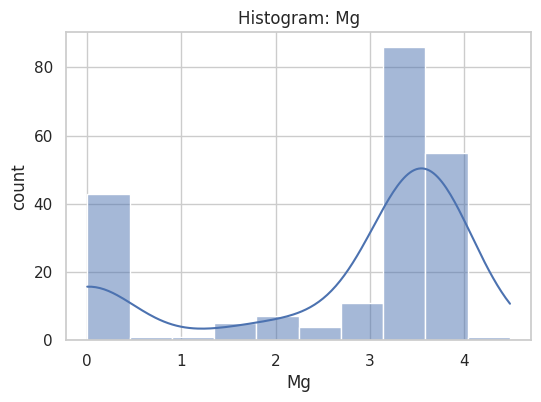

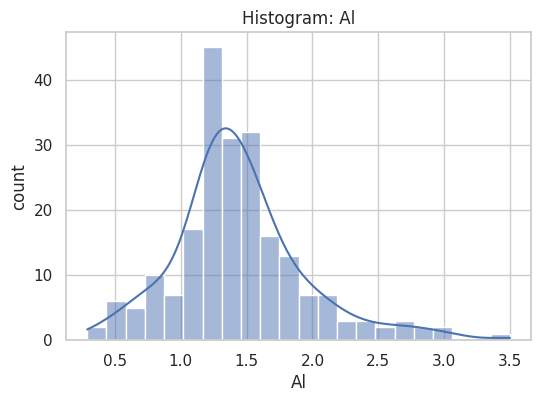

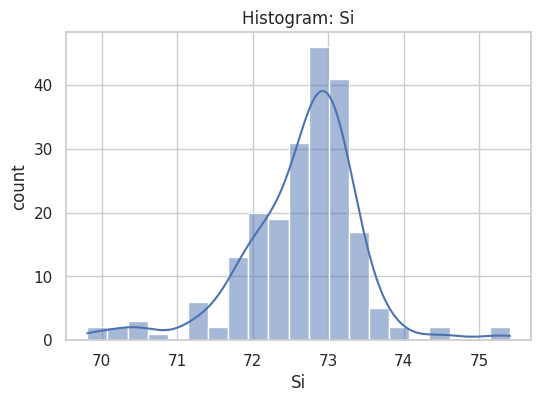

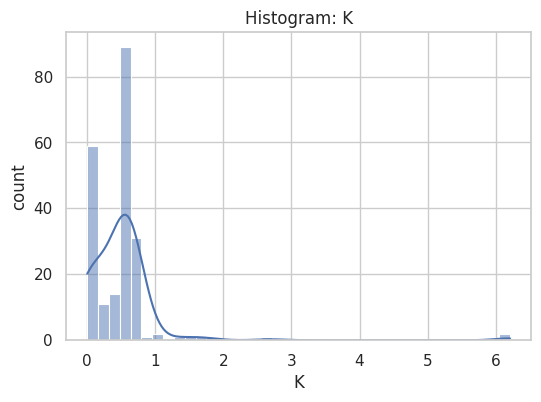

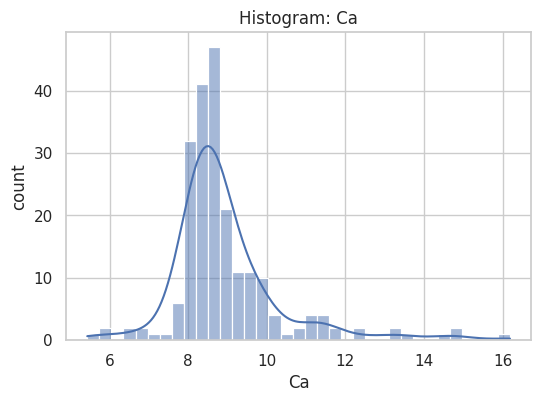

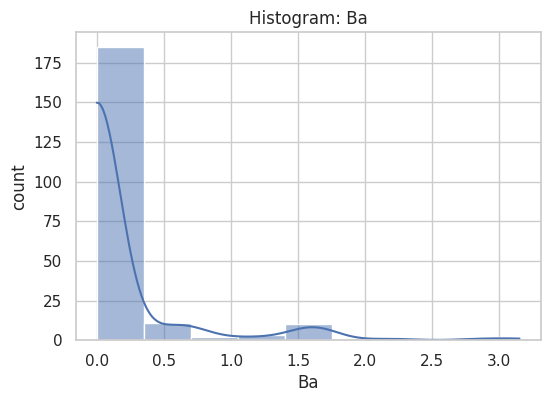

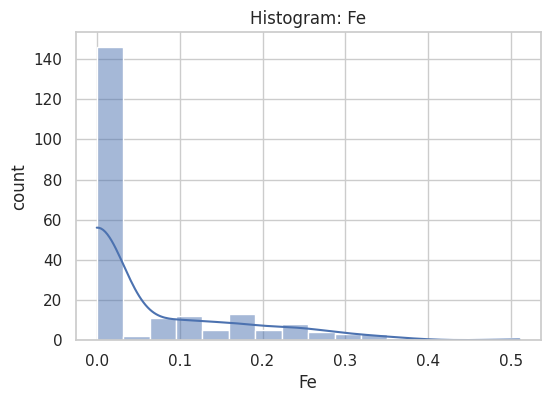

In [5]:
for col in X.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(X[col].dropna(), kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

## Матрица корреляций

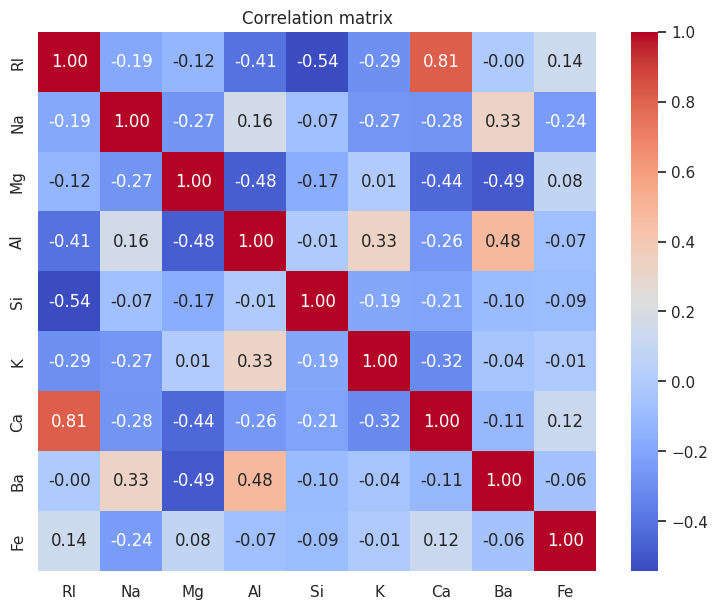

In [6]:
plt.figure(figsize=(9, 7))
sns.heatmap(X.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

## Поиск выбросов

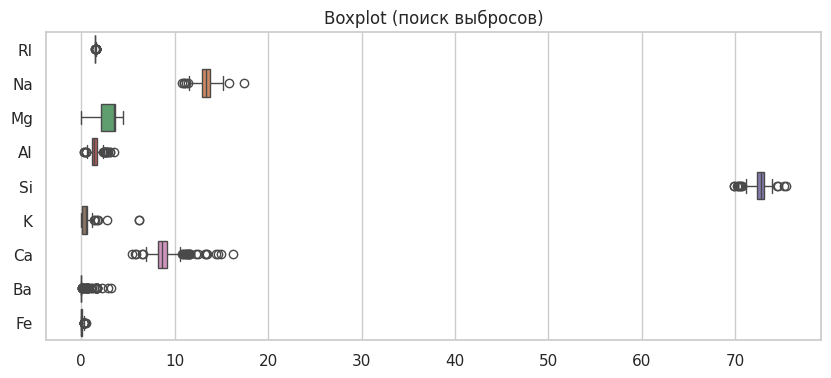

In [7]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=X, orient="h")
plt.title("Boxplot (поиск выбросов)")
plt.show()

## Масштабирование признаков

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,0.872868,0.284953,1.254639,-0.692442,-1.127082,-0.671705,-0.145766,-0.352877,-0.586451
1,-0.249333,0.591817,0.636168,-0.170460,0.102319,-0.026213,-0.793734,-0.352877,-0.586451
2,-0.721318,0.149933,0.601422,0.190912,0.438787,-0.164533,-0.828949,-0.352877,-0.586451
3,-0.232831,-0.242853,0.698710,-0.310994,-0.052974,0.112107,-0.519052,-0.352877,-0.586451
4,-0.312045,-0.169205,0.650066,-0.411375,0.555256,0.081369,-0.624699,-0.352877,-0.586451


## Pairplot (цвет по Type)

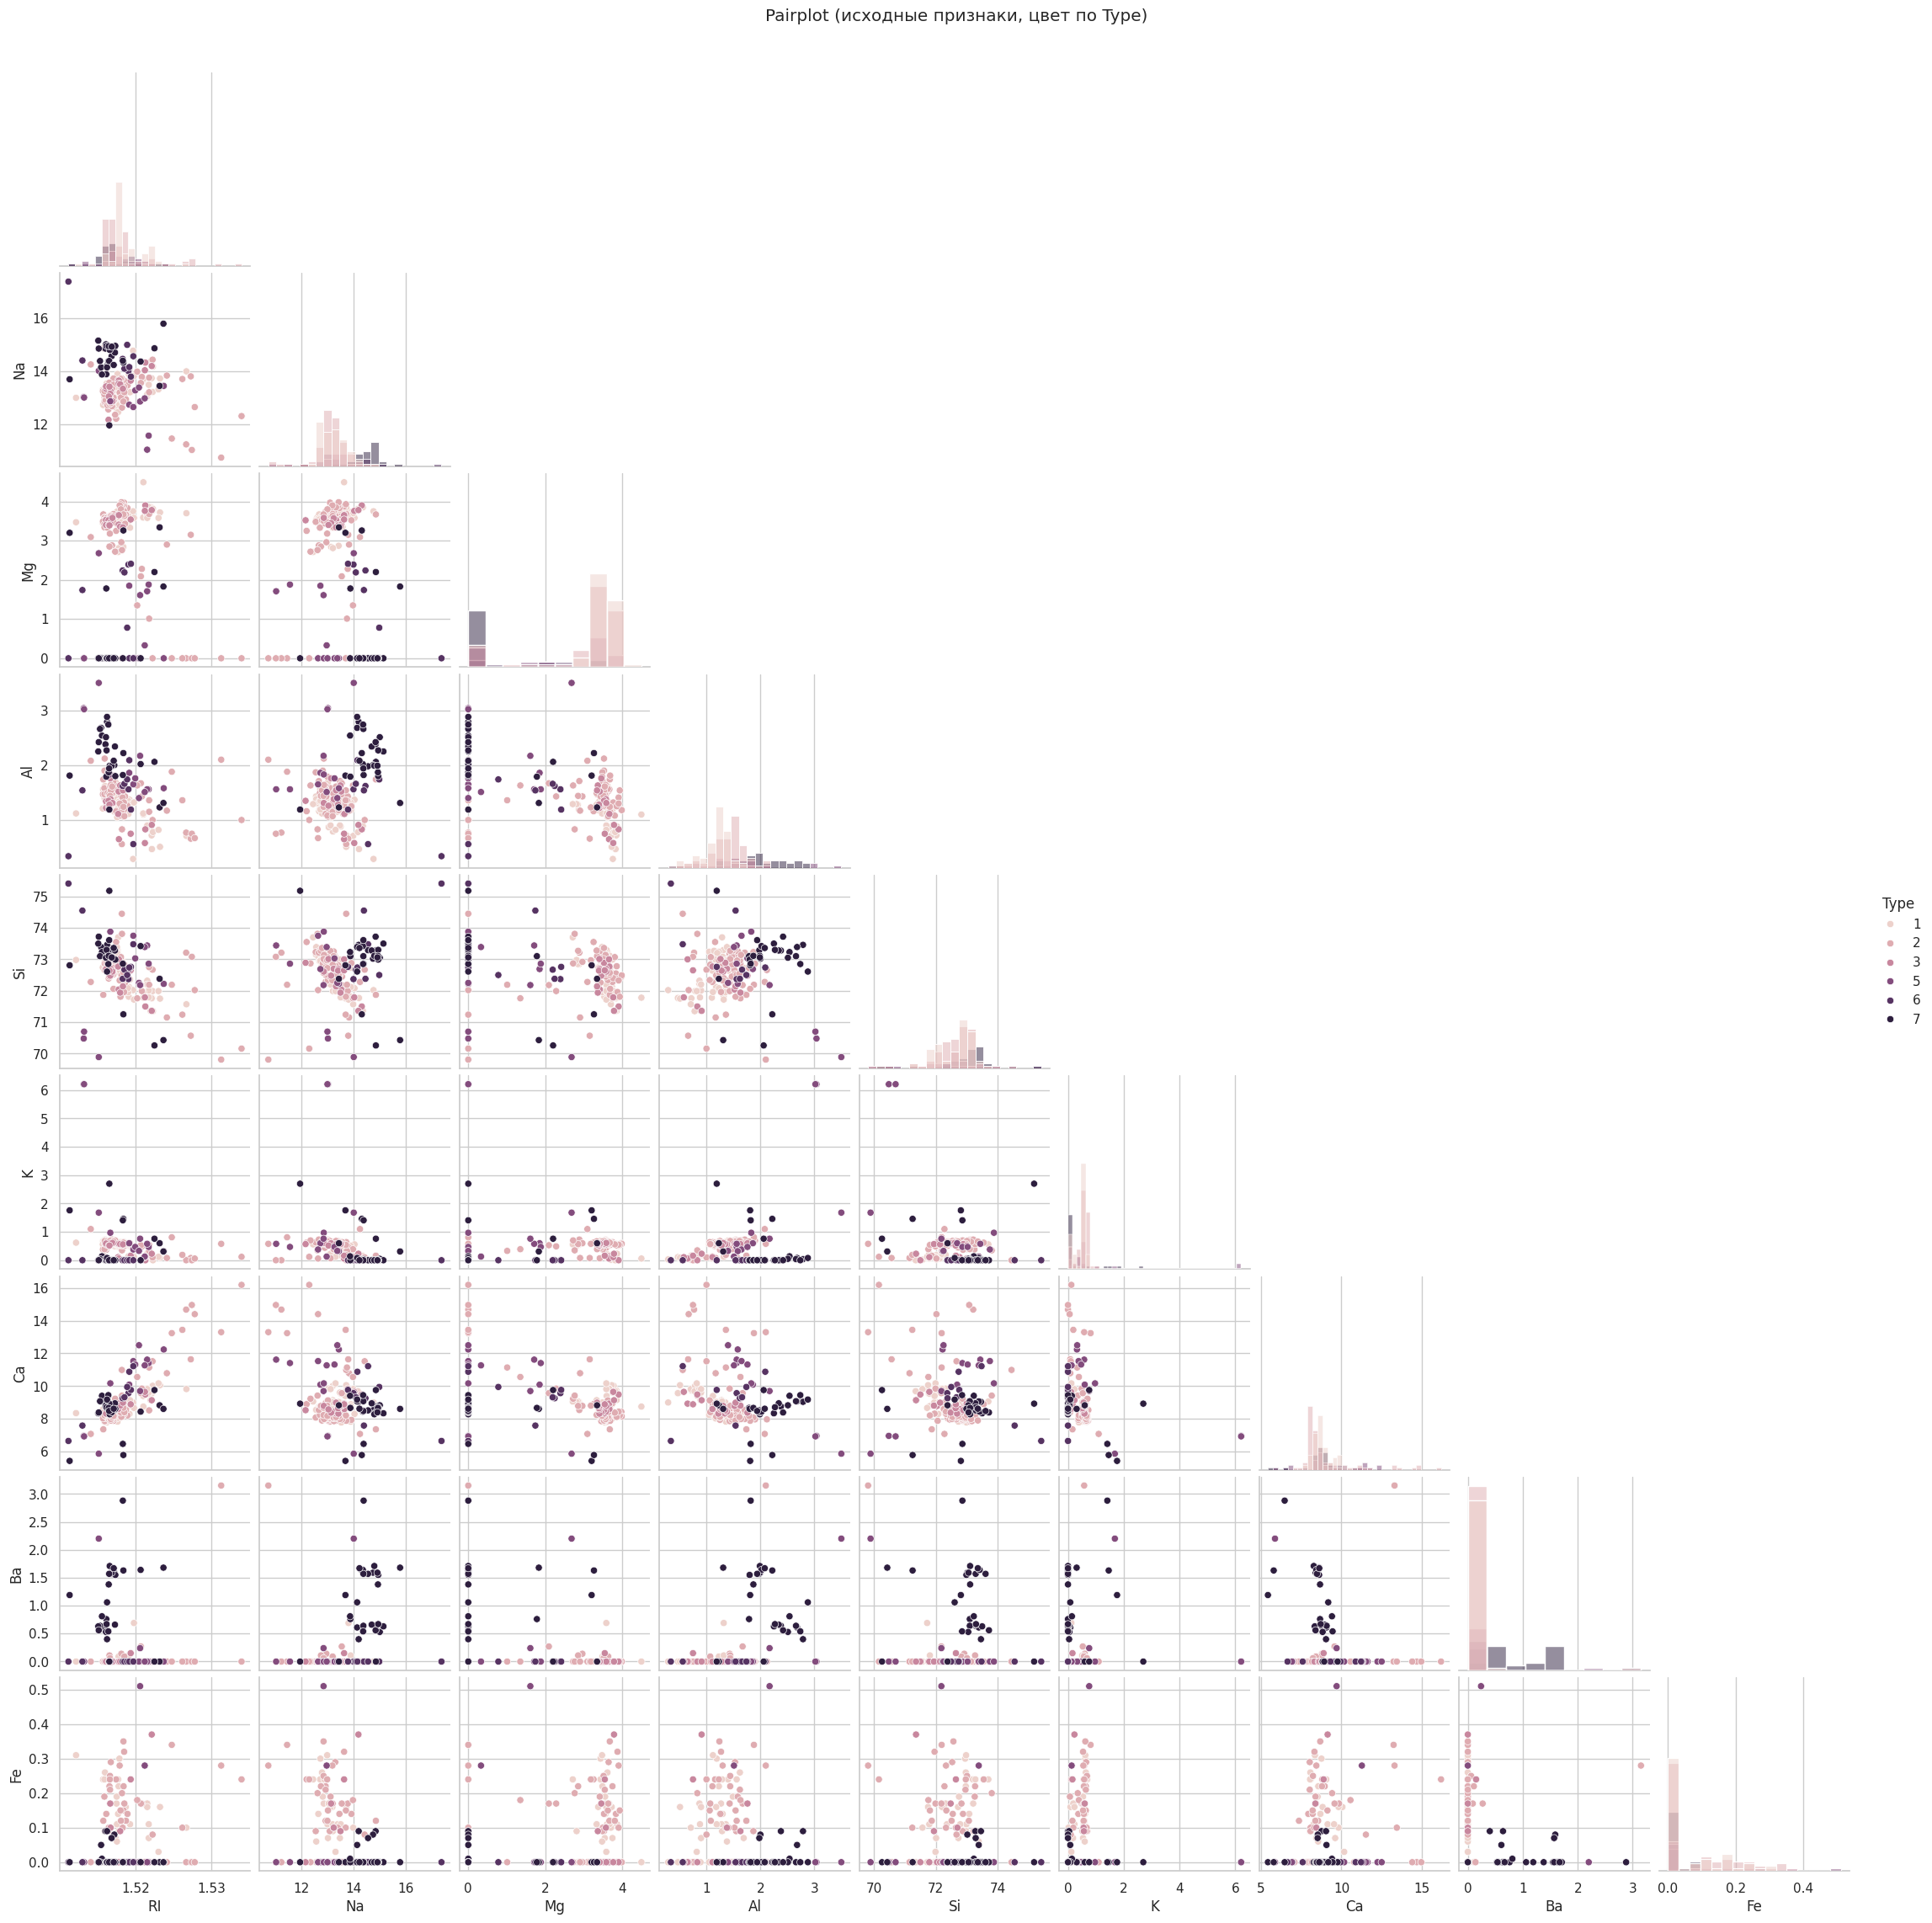

In [9]:
sns.pairplot(pd.concat([X, y_true.rename("Type")], axis=1), corner=True, diag_kind="hist", hue="Type")
plt.suptitle("Pairplot (исходные признаки, цвет по Type)", y=1.02)
plt.show()

## KMeans: подбор числа кластеров

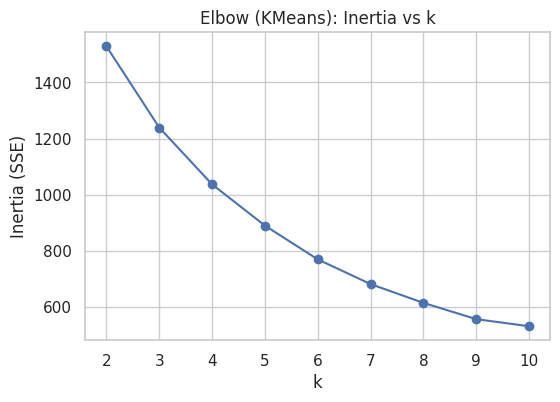

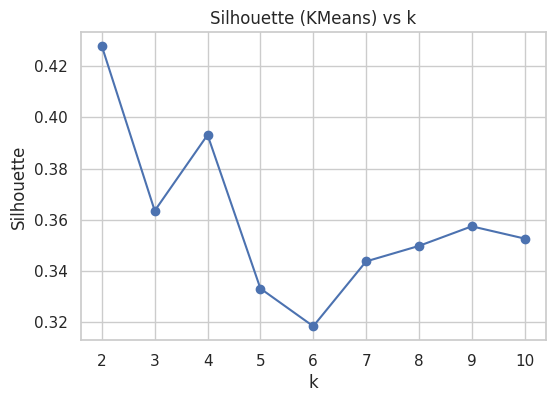

Рекомендованное k по максимуму silhouette (KMeans): 2


In [10]:
K_range = range(2, 11)

inertias = []
sil_km = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_km.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow (KMeans): Inertia vs k")
plt.xlabel("k")
plt.ylabel("Inertia (SSE)")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), sil_km, marker="o")
plt.title("Silhouette (KMeans) vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

best_k_km = list(K_range)[int(np.argmax(sil_km))]
print("Рекомендованное k по максимуму silhouette (KMeans):", best_k_km)

## Иерархическая кластеризация (Ward): подбор k

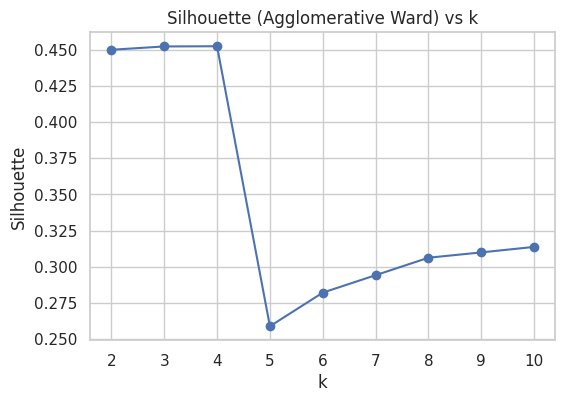

Рекомендованное k по максимуму silhouette (Ward): 4


In [11]:
sil_ward = []
for k in K_range:
    ward_tmp = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = ward_tmp.fit_predict(X_scaled)
    sil_ward.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(K_range), sil_ward, marker="o")
plt.title("Silhouette (Agglomerative Ward) vs k")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

best_k_ward = list(K_range)[int(np.argmax(sil_ward))]
print("Рекомендованное k по максимуму silhouette (Ward):", best_k_ward)

## Дендрограмма (Ward linkage)

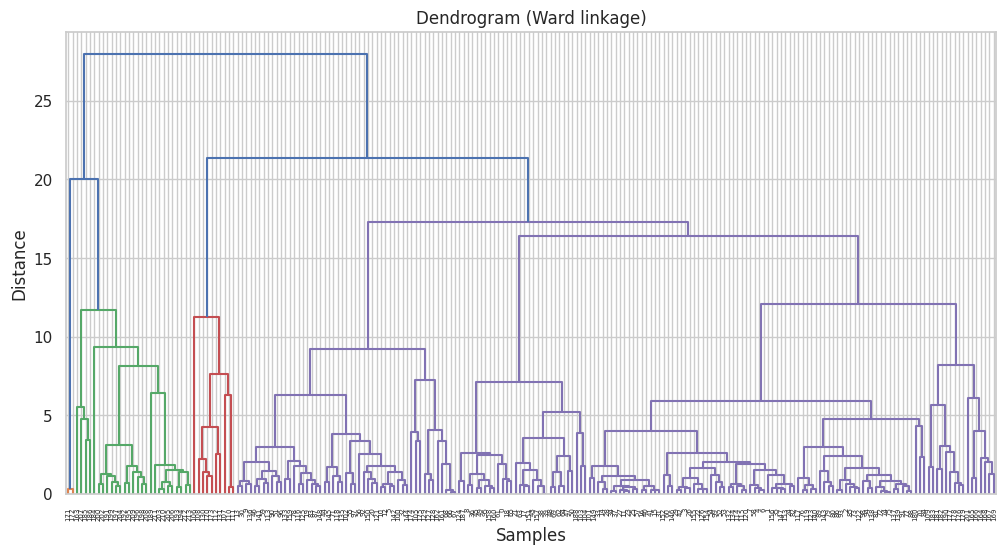

In [12]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram (Ward linkage)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Ward: модель и метрики

In [13]:
k = int(best_k_ward)
ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_ward = ward.fit_predict(X_scaled)

ward_sil = silhouette_score(X_scaled, labels_ward)
ward_ch = calinski_harabasz_score(X_scaled, labels_ward)
ward_db = davies_bouldin_score(X_scaled, labels_ward)

ward_ari = adjusted_rand_score(y_true, labels_ward)
ward_nmi = normalized_mutual_info_score(y_true, labels_ward)

print(f"Ward (k={k}) metrics:")
print("  Silhouette:", round(ward_sil, 4))
print("  Calinski-Harabasz:", round(ward_ch, 2))
print("  Davies-Bouldin:", round(ward_db, 4))
print("  ARI vs Type:", round(ward_ari, 4))
print("  NMI vs Type:", round(ward_nmi, 4))

display(pd.crosstab(y_true, labels_ward, rownames=["Type"], colnames=["Cluster"]))

Ward (k=4) metrics:
  Silhouette: 0.4523
  Calinski-Harabasz: 51.95
  Davies-Bouldin: 0.8431
  ARI vs Type: 0.1732
  NMI vs Type: 0.3384


Cluster,0,1,2,3
Type,,,,
1,70,0,0,0
2,68,0,8,0
3,17,0,0,0
5,8,1,2,2
6,8,1,0,0
7,4,25,0,0


## KMeans: модель и метрики

In [14]:
k = int(best_k_km)
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_km = km.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, labels_km)
km_ch = calinski_harabasz_score(X_scaled, labels_km)
km_db = davies_bouldin_score(X_scaled, labels_km)

km_ari = adjusted_rand_score(y_true, labels_km)
km_nmi = normalized_mutual_info_score(y_true, labels_km)

print(f"KMeans (k={k}) metrics:")
print("  Silhouette:", round(km_sil, 4))
print("  Calinski-Harabasz:", round(km_ch, 2))
print("  Davies-Bouldin:", round(km_db, 4))
print("  ARI vs Type:", round(km_ari, 4))
print("  NMI vs Type:", round(km_nmi, 4))

display(pd.crosstab(y_true, labels_km, rownames=["Type"], colnames=["Cluster"]))

KMeans (k=2) metrics:
  Silhouette: 0.4278
  Calinski-Harabasz: 55.08
  Davies-Bouldin: 1.3583
  ARI vs Type: 0.1991
  NMI vs Type: 0.3146


Cluster,0,1
Type,,
1,0,70
2,1,75
3,0,17
5,3,10
6,4,5
7,26,3


## DBSCAN: k-distance график

D = 9 min_samples = 18


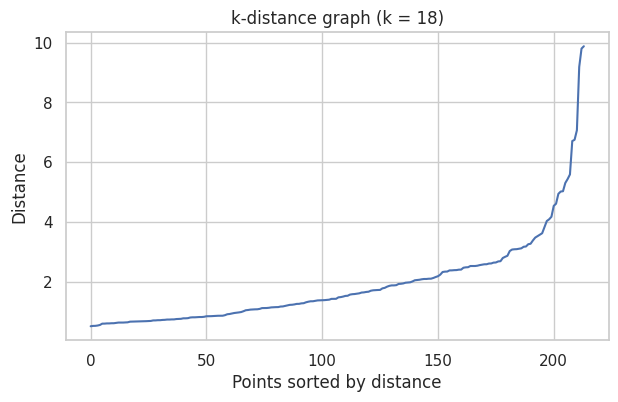

In [15]:
D = X_scaled.shape[1]
min_samples_base = max(3, 2 * D)
print("D =", D, "min_samples =", min_samples_base)

nn = NearestNeighbors(n_neighbors=min_samples_base)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

k_dist = np.sort(distances[:, min_samples_base - 1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.title(f"k-distance graph (k = {min_samples_base})")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.show()

## DBSCAN: перебор параметров

In [16]:
eps_values = np.linspace(0.15, 3.0, 24)
min_samples_values = sorted(set([min_samples_base - 4, min_samples_base - 2, min_samples_base, min_samples_base + 2, min_samples_base + 4]))
min_samples_values = [ms for ms in min_samples_values if ms >= 3]

rows = []
for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=float(eps), min_samples=int(ms))
        labels = model.fit_predict(X_scaled)

        n_noise = int(np.sum(labels == -1))
        clusters = sorted([c for c in set(labels) if c != -1])
        n_clusters = len(clusters)
        noise_share = n_noise / len(labels)

        sil_all = np.nan
        sil_no_noise = np.nan

        if n_clusters >= 2:
            sil_all = float(silhouette_score(X_scaled, labels))
            mask = labels != -1
            if np.sum(mask) > n_clusters and len(set(labels[mask])) >= 2:
                sil_no_noise = float(silhouette_score(X_scaled[mask], labels[mask]))

        rows.append({
            "eps": float(eps),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "noise_share": float(noise_share),
            "silhouette_all": sil_all,
            "silhouette_no_noise": sil_no_noise
        })

grid = pd.DataFrame(rows)
display(grid.sort_values(["silhouette_no_noise", "silhouette_all"], ascending=False).head(15))

,eps,min_samples,n_clusters,noise_share,silhouette_all,silhouette_no_noise
75,2.008696,14,2,0.182243,0.374407,0.518172
82,2.132609,18,2,0.154206,0.391519,0.509597
87,2.256522,18,2,0.130841,0.410878,0.507616
88,2.256522,20,2,0.130841,0.410878,0.507616
94,2.380435,22,2,0.130841,0.410878,0.507616
80,2.132609,14,2,0.149533,0.391014,0.505237
81,2.132609,16,2,0.149533,0.391014,0.505237
86,2.256522,16,2,0.121495,0.416048,0.504596
85,2.256522,14,2,0.107477,0.413583,0.492860
0,0.150000,14,0,1.000000,NaN,NaN


## DBSCAN: лучшая конфигурация и метрики

In [17]:
cand = grid.dropna(subset=["silhouette_no_noise"]).sort_values("silhouette_no_noise", ascending=False)

if len(cand) == 0:
    print("Не найдено параметров DBSCAN, дающих минимум два кластера без шума по текущей сетке")
else:
    best = cand.iloc[0]
    best_eps = float(best["eps"])
    best_ms = int(best["min_samples"])

    db = DBSCAN(eps=best_eps, min_samples=best_ms)
    labels_db = db.fit_predict(X_scaled)

    clusters = [c for c in set(labels_db) if c != -1]
    n_clusters = len(clusters)
    noise_share = float(np.mean(labels_db == -1))

    print("Best DBSCAN params:", {"eps": best_eps, "min_samples": best_ms})
    print("n_clusters:", n_clusters, "noise_share:", round(noise_share, 4))

    if n_clusters >= 2:
        db_sil = float(silhouette_score(X_scaled, labels_db))
        db_ch = float(calinski_harabasz_score(X_scaled, labels_db))
        db_db = float(davies_bouldin_score(X_scaled, labels_db))
    else:
        db_sil = np.nan
        db_ch = np.nan
        db_db = np.nan

    db_ari = adjusted_rand_score(y_true, labels_db)
    db_nmi = normalized_mutual_info_score(y_true, labels_db)

    print("  Silhouette:", None if np.isnan(db_sil) else round(db_sil, 4))
    print("  Calinski-Harabasz:", None if np.isnan(db_ch) else round(db_ch, 2))
    print("  Davies-Bouldin:", None if np.isnan(db_db) else round(db_db, 4))
    print("  ARI vs Type:", round(db_ari, 4))
    print("  NMI vs Type:", round(db_nmi, 4))

    display(pd.crosstab(y_true, labels_db, rownames=["Type"], colnames=["Cluster"]))

Best DBSCAN params: {'eps': 2.008695652173913, 'min_samples': 14}
n_clusters: 2 noise_share: 0.1822
  Silhouette: 0.3744
  Calinski-Harabasz: 29.4
  Davies-Bouldin: 2.167
  ARI vs Type: 0.2246
  NMI vs Type: 0.3349


Cluster,-1,0,1
Type,,,
1,0,70,0
2,10,66,0
3,1,16,0
5,11,2,0
6,4,5,0
7,13,2,14


## Сравнение методов

In [18]:
rows = [
    {
        "method": f"Ward (k={best_k_ward})",
        "n_clusters": int(len(np.unique(labels_ward))),
        "silhouette": float(ward_sil),
        "calinski_harabasz": float(ward_ch),
        "davies_bouldin": float(ward_db),
        "ARI": float(ward_ari),
        "NMI": float(ward_nmi),
        "noise_share": 0.0
    },
    {
        "method": f"KMeans (k={best_k_km})",
        "n_clusters": int(len(np.unique(labels_km))),
        "silhouette": float(km_sil),
        "calinski_harabasz": float(km_ch),
        "davies_bouldin": float(km_db),
        "ARI": float(km_ari),
        "NMI": float(km_nmi),
        "noise_share": 0.0
    }
]

if "labels_db" in globals():
    clusters = [c for c in set(labels_db) if c != -1]
    rows.append({
        "method": f"DBSCAN (eps={best_eps:.3f}, min_samples={best_ms})",
        "n_clusters": int(len(clusters)),
        "silhouette": np.nan if "db_sil" not in globals() else db_sil,
        "calinski_harabasz": np.nan if "db_ch" not in globals() else db_ch,
        "davies_bouldin": np.nan if "db_db" not in globals() else db_db,
        "ARI": float(db_ari),
        "NMI": float(db_nmi),
        "noise_share": float(np.mean(labels_db == -1))
    })

summary = pd.DataFrame(rows)
display(summary)

,method,n_clusters,silhouette,calinski_harabasz,davies_bouldin,ARI,NMI,noise_share
0,Ward (k=4),4,0.452350,51.950331,0.843065,0.173168,0.338365,0.000000
1,KMeans (k=2),2,0.427769,55.084316,1.358349,0.199133,0.314569,0.000000
2,"DBSCAN (eps=2.009, min_samples=14)",2,0.374407,29.395732,2.167043,0.224599,0.334939,0.182243


## Визуализация кластеров в пространстве PCA

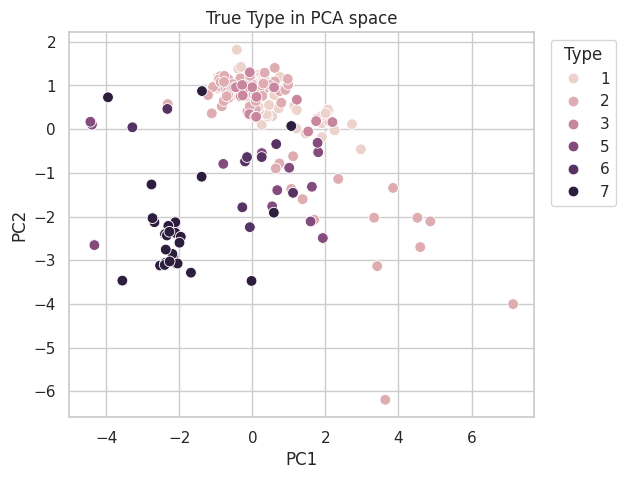

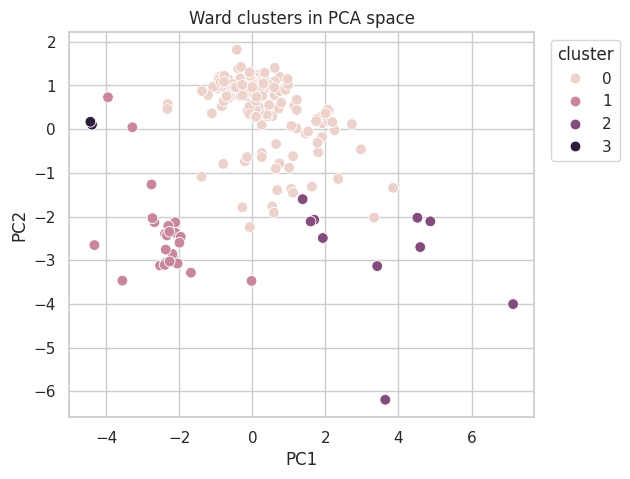

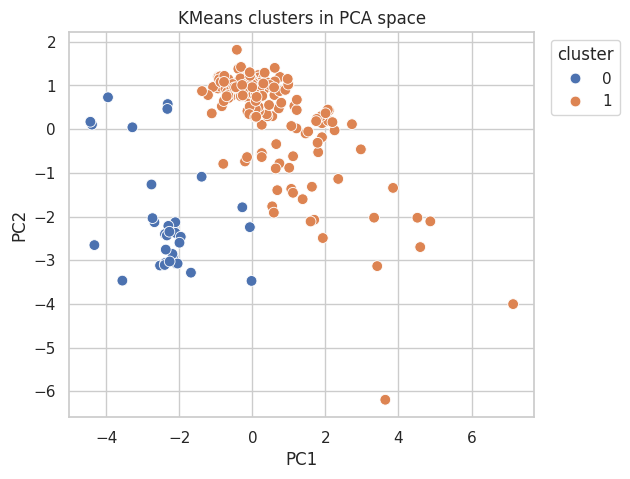

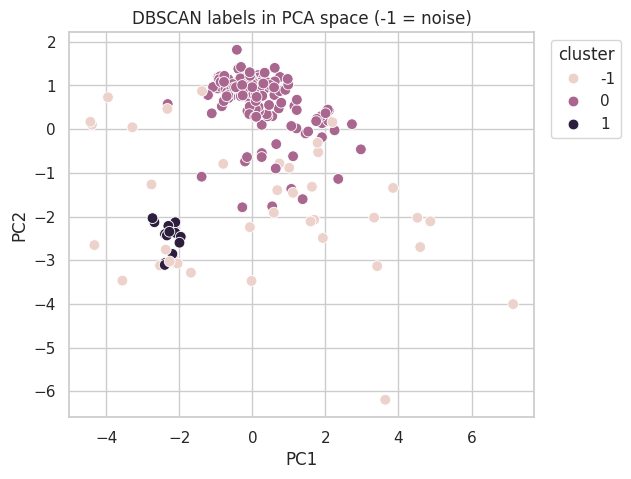

In [19]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Type"] = y_true.astype(int)
pca_df["Ward"] = labels_ward
pca_df["KMeans"] = labels_km

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Type", s=60)
plt.title("True Type in PCA space")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Ward", s=60)
plt.title("Ward clusters in PCA space")
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

plt.figure(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="KMeans", s=60)
plt.title("KMeans clusters in PCA space")
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

if "labels_db" in globals():
    pca_df["DBSCAN"] = labels_db
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="DBSCAN", s=60)
    plt.title("DBSCAN labels in PCA space (-1 = noise)")
    plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

## Вывод

1. Датасет Glass после стандартизации подходит для кластеризации: признаки числовые, а идентификатор Id исключён.
2. Для KMeans и Ward выполнялся подбор числа кластеров по максимуму силуэта; дополнительно рассчитаны Calinski–Harabasz и Davies–Bouldin.
3. Колонка Type не использовалась как признак, но применялась для внешней проверки результата (ARI, NMI).
4. Проекция PCA позволяет визуально оценить разделимость групп и характер пересечений.
5. DBSCAN чувствителен к параметрам, поэтому анализировался k-distance график и выполнялся перебор eps и min_samples.